
\---

\# 工程实施规格 v2.1（全文版）

\## 0. 文档目的与交付目标

本规格用于指导项目的整体工程实现，目标是：

1\. 优先完成一个**\*\*可训练、可评估、可复现实验结果的 MVP\*\***；

2\. 代码结构必须兼容论文完整版本，包括：

`   `\* 多模态对齐；

`   `\* 高频 / 低频触觉解耦；

`   `\* 递归介质信念建模；

`   `\* 对象控制属性建模；

`   `\* 力策略回归；

`   `\* 消融实验；

`   `\* 可视化与论文图表导出；

3\. 当前主线实现不依赖已有数据中缺失的信息，因此：

`   `\* \*\*不启用轻量几何先验 (\tilde d^*\*)\**\*；

`   `\* 保留接口，但不写入默认训练与推理主路径。

本规格分为两个层级：

\* **\*\*MVP 主线\*\***：保证训练闭环、评估闭环、论文核心离线结果可出；

\* **\*\*论文完整版扩展\*\***：在 MVP 之上补充机制实验、在线系统 benchmark、辅助预训练等扩展。

\---

\## 1. 工程交付边界

\### 1.1 MVP 阶段必须交付

MVP 阶段必须完成：

\* 数据预处理流水线；

\* 标注表校验工具；

\* `samples.csv` 与 `windows.csv` 生成；

\* Dataset / DataLoader；

\* 模型训练；

\* 离线评估；

\* 单样本时间线可视化；

\* 消融开关；

\* 断点续训；

\* 配置化实验管理；

\* 在线接口占位与日志规范。

\### 1.2 MVP 阶段不要求的硬交付

MVP 第一阶段**\*\*不要求\*\***完成：

\* 全量真实机器人 rollout；

\* 在线系统 benchmark 的正式主结果采集；

\* 多方法在线硬件对比。

这些属于**\*\*论文完整版阶段交付\*\***。

\### 1.3 最终交付物

必须包含：

\* 源代码；

\* 配置文件；

\* 数据表模板；

\* 运行说明；

\* 实验日志模板；

\* checkpoint 保存规范；

\* 图表导出脚本；

\* 评估脚本；

\* 可视化脚本。

\---

\## 2. 目录结构与路径规范

\### 2.1 标准目录结构

正式冻结以下目录结构：

\```text

data/

├── raw/

│   ├── videos/

│   └── tactile/

├── annotations/

│   ├── object\_attributes.csv

│   └── sample\_events.csv

├── processed/

│   ├── samples.csv

│   ├── windows.csv

│   ├── stats/

│   ├── cache/

│   └── debug/

├── splits/

│   ├── split\_seen\_debug\_v1.yaml

│   ├── split\_unseen\_fold1\_v1.yaml

│   ├── split\_unseen\_fold2\_v1.yaml

│   ├── split\_unseen\_fold3\_v1.yaml

│   ├── split\_unseen\_online\_benchmark\_v1.yaml

│   └── probe\_mechanism\_v1.yaml

└── runs/

\```

\### 2.2 路径规范

在所有 csv / yaml 中：

\* `video\_path`

\* `tactile\_path`

必须保存为**\*\*相对路径\*\***，相对于项目数据根目录 `data/`。

示例：

\```text

raw/videos/OBJ001\_trial03.mp4

raw/tactile/OBJ001\_trial03.txt

\```

\### 2.3 工程要求

\* 代码不得从文件名解析 object\_id 、 sample\_id或实验条件，所有样本关系、对象关系、路径映射与时间事件一律以 csv 字段为准，文件名仅作为文件定位标识，不应承担语义解析功能；

\* 不允许在代码中写死绝对路径；

\* 所有路径统一通过 config 管理；

\* 多人协作、换机训练、远程训练时必须只依赖相对路径与根目录配置。

\---

\## 3. 对象池定义与数据使用原则

\### 3.1 主任务对象池

\* `OBJ001` Ceramic cup

\* `OBJ002` Soup bowl

\* `OBJ003` White bowl

\* `OBJ004` Hammered glass cup

\* `OBJ005` Black bowl

\* `OBJ006` Blue wine glass

\* `OBJ007` Frosted glass cup

\* `OBJ008` Paper milk bottle

\* `OBJ009` Plastic milk bottle

\* `OBJ010` Light-colored wine glass

\* `OBJ011` Mineral water bottle

\* `OBJ012` Dark-colored wine glass

\### 3.2 规则机制对象池

\* `OBJ013` Transparent glass mold

\* `OBJ014` Silicone mold (white, soft)

\* `OBJ015` Silicone mold (white, rigid)

\* `OBJ016` Silicone mold (black)

\* `OBJ017` Silicone cup

\* `OBJ018` Frosted glass mold

\### 3.3 数据使用总原则

\* **\*\*官方主训练 / 主验证 / 主测试\*\***：默认只使用**\*\*主任务对象池\*\***

\* **\*\*规则机制对象池\*\***：默认作为**\*\*机制分析集\*\***

\* 规则机制对象池**\*\*不进入官方主结果训练\*\***

\* 允许在扩展实验中使用规则机制对象池做 **\*\*Stage-0 表征预训练\*\***

\* 但 Stage-0 仅允许预训练感知 / 状态相关模块，**\*\*不得用于策略头预训练\*\***

\* 若论文主表使用规则机制预训练，则所有 baseline 必须获得同等预训练预算；否则只能作为附加实验单独报告

\---

\## 4. 标注表规范

\## 4.1 `object\_attributes.csv`

字段：

\* `object\_id`

\* `object\_name`

\* `object\_pool`（`main` / `mechanism`）

\* `fragility`

\* `geometry`

\* `surface`

\* `notes`

\### 枚举约定

\#### Fragility / Compliance

\* `fragile`

\* `robust`

\* `compliant`

\#### Geometry

\* `cylindrical`

\* `bowl\_like`

\* `cup\_like`

\* `constricted\_opening`

\#### Surface

\* `smooth`

\* `matte`

\### 约束

\* 官方训练版本不允许属性为空；

\* 属性表允许版本化管理。

\---

\## 4.2 `sample\_events.csv`

字段：

\* `sample\_id`

\* `video\_path`

\* `tactile\_path`

\* `object\_id`

\* `water\_condition`

\* `lift\_speed`

\* `placement\_variant`

\* `trial\_id`

\* `trial\_result`

\* `t\_start`

\* `t\_contact\_all`

\* `t\_grasp\_stable`

\* `t\_if\_enter`

\* `t\_if\_exit`

\* `t\_end`

\* `notes`


可选审计字段：

\* `frame\_contact\_all`

\* `frame\_grasp\_stable`

\* `frame\_if\_enter`

\* `frame\_if\_exit`

\* `frame\_end`

\* `sync\_offset\_sec`

\### 枚举约定

\#### `trial\_result`

\* `stable`

\* `partial\_slip`

\* `fail`

\#### `water\_condition`

\* `clear`

\* `turbid`

\#### `lift\_speed`

\* `normal`

\* `fast`

\#### `placement\_variant`

采用：

\* normal / rotate / inverse

说明：

\* 仅表示同一对象下不同摆放协议；

\* 不强制赋予全局统一的角度语义；

\* 默认不作为模型输入，只作为元数据与分析条件。


\### 时间字段要求

必填：

\* `t\_start`

\* `t\_if\_enter`

\* `t\_if\_exit`

\* `t\_end`

推荐填但允许为空：

\* `t\_contact\_all`

\* `t\_grasp\_stable`

约定：

\* `t\_start = 0`

\* t\_contact\_all / t\_grasp\_stable / t\_if\_enter / t\_if\_exit 只填真实发生过的事件，未发生就留空 NaN。

\* fail 的 t\_end 填滑落 / 失败发生时刻，而不是视频结束时刻。

\* 单位统一为秒

\* 帧号字段仅作审计与回查，不作为训练真值

\* 保留到**小数点后 3 位**

\### `t\_contact\_all` 与 `t\_grasp\_stable` 的默认用途

当前 MVP 主线中：

\* **\*\*不作为训练真值\*\***

\* **\*\*不作为主窗口标签生成的硬依赖\*\***

仅用于：

\* 可视化；

\* 审计；

\* 阶段分析；

\* 调试；

\* 后续扩展研究。

若这两个字段为空，不应阻塞主线训练。

\---

\## 5. 样本级总入口表与窗口表

\## 5.1 `samples.csv`

必须生成：

\```text

data/processed/samples.csv

\```

它是**\*\*样本级程序最终入口总表\*\***。

\### 生成方式

`samples.csv` 必须由以下两张表按 `object\_id` 合并生成：

\* `data/annotations/object\_attributes.csv`

\* `data/annotations/sample\_events.csv`

规则：

\* 以 `sample\_events.csv` 为主表；

\* 按 `object\_id` 左连接 `object\_attributes.csv`；

\* 每行对应一个 `sample\_id`；

\* 作为 Dataset 初始化和后续窗口切分的标准入口。

\### 字段

至少包含：

\* `sample\_id`

\* `video\_path`

\* `tactile\_path`

\* `object\_id`

\* `object\_name`

\* `object\_pool`

\* `fragility`

\* `geometry`

\* `surface`

\* `water\_condition`

\* `lift\_speed`

\* `placement\_variant`

\* `trial\_id`

\* `trial\_result`

\* `t\_start`

\* `t\_contact\_all`

\* `t\_grasp\_stable`

\* `t\_if\_enter`

\* `t\_if\_exit`

\* `t\_end`

\* `notes`

\* `sync\_offset\_sec`

\### 作用约定

\* `windows.csv` **\*\*必须由 `samples.csv` 生成\*\***

\* 不允许在训练代码中分别读取两张表再动态 join

\---

\## 5.2 `windows.csv`

必须生成：

\```text

data/processed/windows.csv

\```

它是窗口级训练 / 评估入口表。

\### 生成来源

\* 由 `samples.csv` 离线生成

\### 至少应包含

\* `window\_id`

\* `sample\_id`

\* `object\_id`

\* `window\_start`

\* `window\_end`

\* `window\_center`

\* `phase\_label`

\* `is\_stable\_mask`

\* `tail\_type`

\* `valid\_ratio\_video`

\* `valid\_ratio\_tactile`

\* `num\_video\_frames`

\* `num\_tactile\_points`

\* `video\_frame\_indices\_json`

\* `tactile\_start\_idx`

\* `tactile\_end\_idx`

\* `water\_condition`

\* `lift\_speed`

\* `placement\_variant`

\* `trial\_result`

( video\_frame\_indices\_json：当前窗口内视频帧索引列表，采用 JSON 数组字符串格式存储

` `tactile\_start\_idx、tactile\_end\_idx：当前窗口在原始触觉序列中的起止索引，统一采用半开区间表示，即对应 [tactile\_start\_idx, tactile\_end\_idx)

` `num\_video\_frames：当前窗口内实际纳入的视频帧数量

` `num\_tactile\_points：当前窗口内实际纳入的触觉点数量

` `valid\_ratio\_video：视频模态在该窗口内的有效覆盖比例

` `valid\_ratio\_tactile：触觉模态在该窗口内的有效覆盖比例

)

其中：
valid\_ratio\_video = 实际纳入窗口的视频帧数 / 目标采样帧数

valid\_ratio\_tactile = 实际纳入窗口的触觉点数 / 目标触觉点数

默认用于质量控制 / 调试 / 过滤

默认**不作为模型输入**




3\. `windows.csv` 复杂字段的唯一存储格式

\### 3.1 总原则

`windows.csv` 中尽量只保存：

\* 标量字段

\* 短字符串字段

\* 明确格式的轻量序列字段

不允许不同工程师自行决定某列是 Python list、JSON、还是自定义字符串。

\---

\## 3.2 `video\_frame\_indices\_json` 的格式

视频帧索引正式定义为：

\* **\*\*JSON 数组字符串\*\***

示例：

\```json

"[120,124,128,132,136,140,144,148]"

\```

列名固定为：

\* `video\_frame\_indices\_json`

不再使用 `video\_frame\_indices` 这一模糊列名。

\---

\## 3.3 触觉索引的格式

·  字段名：tactile\_start\_idx

·  ·  字段名：tactile\_end\_idx

·  ·  表示方式：半开区间 [start\_idx, end\_idx)

·  ·  不允许再使用单字段字符串形式的范围表示，如 "100-126" 或 "100:126"


**实现约束**

所有 windows.csv 的生成代码必须严格遵守上述字段名与序列化方式

下游 Dataset 与调试工具也必须按同一规范解析

不允许在不同脚本中混用旧字段名和新字段名

\---

\## 3.4 其他复杂映射信息

如需保存更复杂的信息，例如：

\* 重采样索引映射

\* 原始点到重采样点的对应

\* 更细粒度的 frame-to-sample 对齐信息

这些信息**\*\*不写进 `windows.csv`\*\***，而是写入 sidecar cache 文件，例如：

\```text

data/processed/cache/<sample\_id>/<window\_id>.npz

\```

或等价的稳定格式。

\### 原则

\* `windows.csv` 只保存训练与审计必需的轻量入口信息

\* 高维 / 复杂映射进入 sidecar cache

\---


\---

\## 6. 样本纳入与尾段规则

\### 6.1 主线默认纳入

主监督训练默认纳入：

\* 具备完整视频与触觉；

\* 关键时间点完整；

\* `trial\_result = stable`；

\* 文件匹配正确；

\* 信号未损坏。

\### 6.2 默认不纳入主监督训练

默认不进入主监督训练，但必须保留入库：

\* `partial\_slip`

\* `fail`

它们保留用于：

\* 错误案例分析；

\* 鲁棒性扩展实验；

\* 风险建模与后续研究。

\### 6.3 人工标注层面仅保留一个结束时间字段：

t\_end：该条样本的人工标注结束时刻

其定义如下：

对于 **stable** 样本，t\_end 表示物体完成抓取并转移到台面结束时刻；

对于 **fail** 样本，t\_end 表示物体滑落、脱手或任务终止的时刻；

对于 **partial\_slip** 样本，t\_end 表示本次样本在人工语义上结束的时刻，并在 trial\_result 中明确标记其状态。

本文不再在人工标注表中单独维护 t\_task\_end 与 t\_valid\_end 两个字段。
其中，窗口切分时所需的“多模态有效结束边界”不作为人工标注字段保存，而由程序在预处理阶段自动计算。



\### 6.4 尾段类型

根据 `t\_effective\_end - t\_if\_exit` 定义：

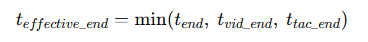

` `t\_vid\_end（视频模态的实际可用结束时刻） **不需要人工标**

` `t\_tac\_end（触觉模态的实际可用结束时刻） **也不需要人工标**

它们都应该由程序**自动从原始文件推出来**

\* `full\_tail`：`>= 1.0 s`

\* `short\_tail`：`0.5 s <= ... < 1.0 s`

\* `< 0.5 s`：不进入完整主训练

\### 6.5 `short\_tail` 的正式使用规则

\#### `full\_tail`

进入所有主线损失：

\* `L\_med`

\* `L\_attr`

\* `L\_clip`

\* `L\_inv`

\* `L\_pol`

\#### `short\_tail`

允许进入主训练，但需打标，并按窗口合法性进入损失：

\* 可以进入 `L\_med`

\* 可以进入 `L\_attr`

\* 可以进入 `L\_pol`

\* 可以进入 `L\_clip / L\_inv`，但仅限样本内部实际存在的 stable Water / stable Air 合法窗口

\#### `< 0.5 s`

不进入完整主训练；

可保留用于分析、可视化、审计。

\### 6.6 评估要求

必须支持以下分组统计：

\* `all\_valid`

\* `full\_tail\_only`

\* `short\_tail\_only`

\---

\## 7. 时间轴、同步与窗口切分

\## 7.1 时间轴

\* 视频时间轴：**\*\*30 Hz\*\***

\* 触觉时间轴：`t\_j = j \* 0.039`

\### 同步规则

\* 默认 `sync\_offset\_sec = 0`

\* 允许对个别样本做单样本偏移修正

\* 必须实现时间轴 sanity check 工具

\* 若视频总长与触觉总长不一致，以重叠最短区间为准

\## 2. `sync\_offset\_sec` 的使用规则

**生成 windows.csv 时，必须先将 sync\_offset\_sec 应用于样本时间轴，再进行窗口切分;**

\## 2.1 默认值

\* 默认 `sync\_offset\_sec = 0.0`

\## 2.2 谁可以修改

`sync\_offset\_sec` 不是工程师可随意更改的训练参数，而是**\*\*数据审计字段\*\***。

只有以下角色可以修改：

\* 数据标注负责人 / 数据维护者

\* 项目 owner 审核通过后的正式修订

工程师不得在本地脚本里私自覆盖或临时硬编码修正。

\---

\## 2.3 何时允许修正

仅当通过**\*\*视频-触觉联合可视化审计\*\***发现存在**\*\*稳定且可重复的跨模态偏移\*\***时，才允许修改。

至少满足以下条件之一：

1\. 在同一样本中，两个及以上锚点事件存在一致方向的时序偏差；

2\. 偏差幅度大于 **\*\*1 个视频帧\*\***（约 `0.033 s`）；

3\. 偏差不是由尾部裁剪、标签错误或单点噪声造成。

推荐用于审计的锚点事件包括：

\* `t\_contact\_all`

\* `t\_grasp\_stable`

\* `t\_if\_enter`

\* `t\_if\_exit`

\* 明显的触觉突变点 / 接触建立点 / 卸载点

\---

\## 2.4 修正依据

修正依据必须来自：

\* 单样本时间线可视化

\* 视频帧与触觉曲线的人工对照审计

不允许仅凭模型效果不好就修改 `sync\_offset\_sec`。

\---

\## 2.5 修正后写回位置

一旦决定修正，必须：

1\. 将修正值写回 `data/annotations/sample\_events.csv` 中该样本的 `sync\_offset\_sec`

2\. 在 `notes` 或单独审计字段中记录修正原因

3\. 重新生成：

`   `\* `data/processed/samples.csv`

`   `\* `data/processed/windows.csv`

不允许只在内存或训练脚本运行时临时覆盖。

\---

\## 2.6 审计建议

建议新增可选字段：

\* `sync\_audit\_status`

\* `sync\_audit\_note`

用于记录：

\* `default\_zero`

\* `manually\_corrected`

\* 修正依据简述

这两个字段可选，但推荐保留。

\---


\---

\## 7.2 窗口切分

固定参数：

\* 窗口长度 `L = 1.0 s`

\* 步长 `S = 0.25 s`

规则：

\* 尾部不足 `1.0 s` 的窗口全部丢弃

\* 统一按时间区间切分，不按固定帧数 / 固定行数硬切

\---

\## 7.3 三相主标签生成

\### `Interface`

若窗口与界面区间 `[t\_if\_enter, t\_if\_exit]` 重叠时间 `>= 0.25 s`，则标记为 `Interface`

\### 其余窗口

按窗口中心时刻判定为：

\* `Water`

\* `Air`

\### stable mask

\* margin 固定 `0.25 s`

\* 仅 stable Water / stable Air 窗口进入：

`  `\* `L\_clip`

`  `\* `L\_inv`

\### 其余损失

合法窗口均可进入：

\* `L\_med`

\* `L\_pol`

\---

\## 8. 原始数据格式与预处理

\## 8.1 视频预处理

\* 原始视频保留不变

\* 模型输入统一 resize / crop 到 `224 x 224`

\* 默认按固定ROI裁剪（全局固定 ROI (460, 28, 1024, 1024)），详情见后文ROI相关规则

\* 保留 RGB

\* 使用 CLIP 标准 mean / std

\* MVP 默认不做激进增强

\* 默认每窗口均匀采样 **\*\*8 帧\*\***

\* `num\_frames\_per\_window` 必须配置化

\* 论文版建议补一个 `8 vs 12` 小对照

若窗口帧覆盖率：

\* `>= 80%`：允许最近邻重复补齐

\* `< 80%`：丢弃窗口并记录 warning

\---

\## 8.2 触觉原始格式

正式定义：

\* 每 `39 ms` 采样一行

\* 每行 `36` 个有符号整数

\* 允许逗号结尾

\* 三指排列：

`  `\* 前 12 个：手指 0

`  `\* 中间 12 个：手指 1

`  `\* 后 12 个：手指 2

\* 每指 12 个数 = `4 个传感器 × 3 轴力`

\* 每 3 个数构成一个传感器的 `(x, y, z)`

单行 canonical reshape 为：

[

[3\ \text{fingers},\ 4\ \text{sensors},\ 3\ \text{axes}]

]

\### 法向轴定义

\* 法向力对应 `z` 轴

\* 三指一致

\* 四个传感器一致

\### 几何分布说明

\* 三指在末端圆盘上中心对称分布，圆心角各 `120°`

\* 每指四个传感器在局部接触面上呈矩形四顶点分布

\---

\## 8.3 主模型输入与 expert 标签路径分离

\### 主模型输入

主模型输入**\*\*不做先验压缩\*\***，直接保留 **\*\*36 通道原始触觉\*\***。

即：

\* 高频内容分支输入：36 通道 `T\_high`

\* 低频证据分支输入：36 通道 `T\_low`

\### expert / 在线测力路径

法向力标签与在线测量统一采用 z 轴聚合路径。

\---

\## 8.4 触觉 AC/DC 分解

采用 EMA：

[

T\_{low} = \mathrm{EMA}(T,\alpha)

]

[

T*\_{high} = T - T\_*{low}

]

默认：

\* `alpha = 0.1`

必须配置化，支持 sweep。

\### 清洗与标准化

\* `NaN / Inf` 处理

\* 越界裁剪

\* 使用 train split 统计量做 channel-wise 标准化

\* 不做 per-sample 标准化

\### 重采样

\* 每窗口重采样到固定长度，默认 `26` 点

\* 必须保留原始区间、原始点数、覆盖率和索引映射到 metadata / debug cache

\* 有效覆盖率 `< 80%` 的窗口丢弃

\---

\## 9. 模型结构

\## 9.1 总体结构

采用三流架构：

1\. **\*\*语义流\*\***

`   `\* 视觉表征

`   `\* 高频触觉内容表征

`   `\* 学习对象内容表示 `z\_content`

2\. **\*\*物理流\*\***

`   `\* 低频触觉证据

`   `\* 递归介质信念推断

`   `\* 输出 `p\_medium`

3\. **\*\*任务流\*\***

`   `\* 基于内容表征与视觉辅助推断对象控制属性

`   `\* 构造 `g\_obj`

策略头输入：

\* `h\_v`

\* `z\_content`

\* `g\_obj`

\* `p\_medium`

输出窗口级期望法向力：

[

F\_{des}(W)

]

\---

\## 9.2 视觉编码器

\* backbone：`CLIP ViT-B/16`

\* 使用 LoRA

\* CLIP 主干默认冻结，仅 LoRA 可训练

\* 使用 Temporal Attention Pooling

\* 命名固定：

`  `\* `h\_v`：供属性 / 策略使用

`  `\* `z\_v`：供对齐损失使用

禁止混用 `h\_v / z\_v / raw\_visual\_feat`。

**Visual Temporal Attention Pooling**
输入为窗口内 T 个 CLIP [CLS] token（每个 512 维）；先对每帧做 LayerNorm，再经 512→256 的线性层和 GELU 得到打分隐变量；使用单个可学习全局 query 生成每帧 attention score，并对合法帧做 masked softmax；用该权重对原始 512 维帧特征加权求和；再与合法帧均值做残差相加，最后经 LayerNorm 输出 h\_v ∈ R^{512}；默认 T=8（num\_frames\_per\_window 须配置化，方便后面补8vs12的对照），补齐帧不参与有效 attention 与 mean 统计。
### **pooling 内部的规范**
目前版本接定死为：

- pre\_norm = true
- activation = GELU
- score\_hidden\_dim = 256
- num\_queries = 1
- num\_heads = 1
- dropout = 0.0
- output\_post\_norm = true
- use\_mean\_residual = true

h\_v -> z\_v 这个视觉投影头虽然在结构上已经定义了，但 **Stage 1 没有** L\_clip，因此它默认不承担主监督。

工程做法是：**Stage 1 可以实例化** z\_v **投影头，但默认不把它加入 optimizer，或者即便加入也接受它几乎无梯度更新**；真正让它进入有效训练的是 Stage 2 的 L\_clip + L\_inv。

我们现在把**\*\*视觉 temporal attention pooling\*\***冻结成下面这版唯一默认实现。

\---

\## 冻结的默认实现

\### 1) 输入与输出

输入是窗口内每帧经过 `CLIP ViT-B/16 + LoRA` 后的 `[CLS]` token 序列

[

X = [x\_1,\dots,x\_T], \quad x\_t \in \mathbb{R}^{512}

]

其中默认 `T = 8`，但保持配置化。输出为窗口级视觉表征

[

h\_v \in \mathbb{R}^{512}

]

这和规格里 `input dim = 512`、`hidden dim = 256`、`output dim = 512` 一致。论文设计文档也明确说视觉端是“逐帧取 [CLS] token，再做时序注意力池化，得到窗口特征”。

\### 2) 打分网络

我建议不要直接用最原始的 `x\_t Q^T`，而是把规格里的 `hidden dim = 256` 用在**\*\*打分 MLP\*\***上，做成：

[

\tilde{x}\_t = \mathrm{LN}(x\_t)

]

[

u\_t = \mathrm{GELU}(W\_1 \tilde{x}\_t + b\_1), \quad W\_1: 512 \to 256

]

[

s\_t = \frac{q^\top u\_t}{\sqrt{256}}, \quad q \in \mathbb{R}^{256}

]

[

\alpha\_t = \mathrm{Softmax}(s\_t + m\_t)

]

其中 `q` 是**\*\*可学习全局查询向量\*\***，这和论文里写的 learnable global query 完全一致；`m\_t` 是 mask，合法帧取 0，非法帧取 `-inf`。这样既保留了论文原意，又把工程规格里的 256 hidden dim 用到了最自然的位置。

\### 3) 聚合方式

我建议**\*\*attention 权重在打分空间里算，但最终加权的是原始 512 维帧特征\*\***，不是 256 维隐藏特征：

[

c = \sum\_{t=1}^{T} \alpha\_t x\_t

]

原因很简单：`h\_v` 后面要直接给属性模块和策略模块用，规格也要求 `h\_v` 是 512 维主表征，而 `z\_v` 才是后面的对齐投影空间。也就是说，pooling 应该负责“挑时间”，不应该顺手把视觉主干表征压扁到另一个语义空间。

\### 4) 残差式稳态汇聚

我建议最终输出不要只用纯 attention sum，而是加一个均值残差：

[

m = \mathrm{Mean}\_{valid}(x\_t)

]

[

h\_v = \mathrm{LN}(c + m)

]

论文里引入 attention pooling 的动机是“避免平均池化抹平瞬态”，但如果完全只靠 attention，早期训练时容易把权重过度压到某一两帧，尤其 Stage 1 只有属性监督、没有对比学习时更容易不稳。加一个 mean residual，可以保留整体上下文，又让 attention 去强调关键时刻。这个折中非常适合现在的训练范式。



\---

\## 9.3 触觉编码器

\### 高频内容编码器

\* 输入：36 通道 `T\_high`

\* 默认结构：轻量 `1D CNN`

\* 输出：`z\_content`

\* 维度：`256`

\### 低频证据编码器

\* 输入：36 通道 `T\_low`

\* 默认结构：轻量 `1D CNN`

\* 输出：`z\_med`

\* 维度：`128`

要求：

\* 两支编码器参数不共享

\* 必须保留 registry / config 接口，未来可替换为 transformer

\---

\## 9.4 介质信念模块

\* 使用单层 GRU

\* hidden size：`128`

\* 输入：`z\_med`

\* 输出：`p\_medium = [p\_water, p\_interface, p\_air]`

说明：

\* 不使用几何先验 (\tilde d^\*)

\* 不依赖 TCP、水面高度或显式位姿

\* 轨迹内递归保留 hidden state

\* 样本边界重置 hidden state

类别权重默认：

\* `Water = 1.0`

\* `Interface = 2.0`

\* `Air = 1.0`

\---

\## 9.5 多属性模块

\* 默认启用视觉辅助

\* 三条属性头共享 trunk

\* 输出：

`  `\* `q\_frag`

`  `\* `q\_geom`

`  `\* `q\_surf`

\* 同时输出三条熵

\* 拼接后投影为 `g\_obj`

要求：

\* `g\_obj` 进入策略前做 `stop-gradient`

\* 日志与可视化必须输出属性不确定性

\---

\## 9.6 策略头

\* 输出：单一标量 `F\_des`

\* 含义：窗口级期望法向力

\* 使用 FiLM，以 `p\_medium` 对策略 MLP 连续调制

\* 默认 FiLM 插入第一隐藏层

\---

\## 9.7 轻量几何先验

当前版本：

\* `use\_geom\_prior = false`

要求：

\* 保留接口

\* 但不得进入默认主训练 / 主推理逻辑

\---

\## 10. 默认模型超参数

\## 10.1 视觉模块

\### CLIP + LoRA

\* backbone：`ViT-B/16`

\* LoRA rank：`8`

\* LoRA alpha：`16`

\* LoRA dropout：`0.0`

\* target modules：`q\_proj`, `v\_proj`

\### Temporal Attention Pooling

\* input dim：`512`

\* hidden dim：`256`

\* output dim（`h\_v`）：`512`

\### 视觉投影头

\* `h\_v -> z\_v`

\* hidden dim：`512`

\* output dim（`z\_v`）：`256`

\---

\## 10.2 触觉模块

\### 高频内容编码器

\* encoder type：`1D CNN`

\* output dim（`z\_content`）：`256`

\### 低频证据编码器

\* encoder type：`1D CNN`

\* output dim（`z\_med`）：`128`

\### 输入长度

\* per-window tactile length：`26`

\---

\## 10.3 介质信念模块

\### GRU

\* num layers：`1`

\* hidden size：`128`

\### 介质分类头

\* input dim：`128`

\* hidden dim：`128`

\* output classes：`3`

\---

\## 10.4 属性模块

\### 共享 trunk

\* input：`[z\_content ; h\_v]`

\* hidden dim：`256`

\### 三个属性头

\* each head hidden dim：`128`

\### `g\_obj` 投影

\* projected dim：`128`

\---

\## 10.5 策略模块

\### 输入

\* `[h\_v ; z\_content ; g\_obj ; p\_medium]`

\### MLP

\* num layers：`2`

\* hidden dim：`256`

\* output dim：`1`

\### FiLM 生成器

\* conditioning input：`p\_medium`

\* hidden dim：`128`

\* applied layer：policy MLP 第一隐藏层

\---

\## 10.6 对比学习超参数

\### InfoNCE

\* temperature：`0.07`

\### SupCon

\* temperature：`0.07`

\---

\## 11. expert 标签生成

正式唯一版本：

\```text

normal\_axis = z

normal\_reduce = signed-sum-after-sign-calibration

\```

\### 定义

1\. 取每个传感器的 `z` 轴值；

2\. 根据统一配置 `normal\_sign` 做符号校准，使“受压法向力”为正；

3\. 对每指四个传感器做**\*\*带符号求和\*\***；

4\. 三指再做**\*\*带符号求和\*\***；

5\. 得到总法向力 `F\_sum(t)`；

6\. 对 `F\_sum(t)` 做 EMA 平滑，默认 `alpha = 0.1`；

7\. 在窗口内取均值，得到：

[

F\_{expert}(W)

]

约束：

\* 不采用 `abs-sum`

\* 不采用“先求和后取绝对值”

\* 不允许工程师自选变体

> **术语冻结说明：`normal_axis`、原始 z 符号与 `normal_sign` 的关系**
>
> 1. 本项目中，触觉原始数据的法向轴固定定义为 **`z` 轴**。这表示在 expert 标签生成与在线 `F_meas` 记录路径中，法向力只从每个传感器的 `z` 通道提取，不再从 `x / y` 轴推断。
>
> 2. 需要明确区分两个层次：
>
>    * **原始 z 符号**：表示传感器局部坐标系中沿 `z` 轴的方向性，即 `+z` 与 `-z` 是两个相反方向；
>    * **任务语义中的法向正负**：表示在本项目中统一约定的“受压法向力为正”的工程语义。
>      这两者相关，但**不能默认等同**。
>
> 3. 因此，官方唯一允许的 expert / 在线测力聚合协议固定为：
>    `normal_axis = z`
>    `normal_reduce = signed-sum-after-sign-calibration`
>    即：先取每个传感器的 `z` 轴值，再根据统一配置 `normal_sign` 做符号校准，将不同传感器/手指的原始方向统一映射到“受压法向力为正”的共同语义；之后才进行带符号求和。
>
> 4. `normal_sign` 的职责不是重新定义传感器坐标轴，而是把**原始测量方向**转换为**项目统一的法向受压语义**。换句话说：
>
>    * 原始 z 值反映“沿本地 z 轴的哪个方向”；
>    * `normal_sign` 校准后的值才反映“这是否对应我们定义的法向受压为正”。
>
> 5. 为保证训练、评估和在线部署的一致性，`F_expert(W)` 与在线 `F_meas(t)` 必须共享同一套 z 轴聚合与 `normal_sign` 校准协议，不允许一个用于训练、另一个用于部署。规格已明确要求在线记录中的 `F_meas(t)` 也由 z 轴聚合得到。
>
> 6. 工程冻结要求：
>
>    * `normal_sign` 必须写入配置并版本化；
>    * 不允许在运行时动态估计 `normal_sign`；
>    * 不允许改用 `abs-sum`、也不允许“先求和后取绝对值”；
>    * 不允许工程师自行替换为其他变体。
>
> 7. 当前建议的实现形式是：`normal_sign` 使用**按手指 / 传感器显式展开的固定配置表**。即使当前所有项恰好取值相同，也仍按显式表保存，而不是收缩成模糊的单一全局符号。这样更利于审计、版本控制与后续硬件差异管理。这个实现建议是对规格中“统一配置 `normal_sign`”的工程化落地，不改变规格语义。

\### 样本范围

\* 默认只从 `stable` 样本生成 expert

\* `partial\_slip / fail` 不生成主线 expert 标签

\* 原始曲线保留用于分析

\---



\## 12. 损失函数与默认权重

完整五损失：

[

L\_{total}

\=========

\lambda*\_{clip}L\_*{clip}

+\lambda*\_{inv}L\_*{inv}

+\lambda*\_{med}L\_*{med}

+\lambda*\_{attr}L\_*{attr}

+\lambda*\_{pol}L\_*{pol}

]

默认权重：

\* `lambda\_clip = 1.0`

\* `lambda\_inv = 0.5`

\* `lambda\_med = 1.0`

\* `lambda\_attr = 1.0`

\* `lambda\_pol = 2.0`

属性内部权重：

\* `lambda\_f = 1.0`

\* `lambda\_g = 1.0`

\* `lambda\_s = 1.0`

具体形式：

\* `L\_clip`：InfoNCE

\* `L\_inv`：SupCon

\* `L\_med`：三分类交叉熵

\* `L\_attr`：三头交叉熵

\* `L\_pol`：MSE

`L\_inv` 正样本：

\* 同 `object\_id` 的 stable Water / stable Air 窗口

\---

\## 13. Interface 类不均衡处理

\### 默认策略

默认只使用：

\* class weight

默认权重：

\* `Water = 1.0`

\* `Interface = 2.0`

\* `Air = 1.0`

\### 默认关闭

\* Interface oversampling 默认关闭

\### 触发启用条件

若前两轮 pilot 实验中，验证集满足任一条件：

1\. `F1\_Interface < 0.60`

2\. `F1\_Interface` 比 `Water / Air` 平均 F1 低 `10` 个点以上

则下一轮实验必须启用：

\* `2x Interface oversampling`

不允许工程师在没有记录理由的情况下随意改 sampler。

\---

\## 14. 训练流程

采用四阶段训练：

\### Stage 1

训练：

\* 高频内容编码器

\* 低频证据编码器

\* 介质 GRU

\* 属性模块

\* 视觉 LoRA

\* 视觉时序池化

\* 相关投影头

损失：

\* `L\_med + L\_attr`

\### Stage 2

在 Stage 1 基础上加入：

\* `L\_clip + L\_inv`

\### Stage 3

默认冻结大部分上游 encoder，仅训练：

\* 策略头

\* FiLM

\* `g\_obj` 投影相关部分

损失：

\* `L\_pol`

\### Stage 4

联合微调全部可训练模块。

说明：

\* CLIP 主干始终冻结，仅 LoRA 可训练

默认 epoch 上限：

\* Stage 1：20

\* Stage 2：20

\* Stage 3：15

\* Stage 4：15

Early stopping：

\* patience = 8

\---

\## 15. 优化与 batch 组织

\### 优化器

\* `AdamW`

\### 学习率

\* 新增模块：`1e-4`

\* LoRA：`5e-5`

\### Scheduler

\* cosine decay + warmup

\* warmup ratio：`0.1`

\### 训练细节

\* 混合精度：开启

\* 梯度裁剪：`max\_norm = 1.0`

\* 随机种子：`42`

\---

\## 15.1 batch 组织原则

训练基本单位：

\* **\*\*sample trajectory\*\***

但 sampler 必须：

\* **\*\*object-aware\*\***

\* 尽量保证 batch 内存在：

`  `\* 同 object 的不同 sample

`  `\* 不同 object 的负样本

推荐默认组织：

\* `4 objects × 2 trajectories = 8 trajectories / batch`

\### 损失计算组织

\* 介质信念与策略学习：沿 trajectory 展开

\* `L\_clip / L\_inv`：从 batch 内 eligible windows flatten 后组织

要求：

\* `L\_inv` 正样本优先来自同 `object\_id`、不同 `sample\_id`

\* `L\_clip` 正样本为同窗口内视-触对

\* 负样本来自 batch 内其他对象 / 其他窗口

\---

\## 16. 官方 split 与实验协议

\## 16.1 官方 split 文件

官方结果必须使用预先固定并保存的 split 文件：

\* `data/splits/split\_unseen\_fold1\_v1.yaml`

\* `data/splits/split\_unseen\_fold2\_v1.yaml`

\* `data/splits/split\_unseen\_fold3\_v1.yaml`

\* `data/splits/split\_seen\_debug\_v1.yaml`

不允许运行时随机生成官方 fold。

\---

\## 16.2 unseen-object 的划分粒度

官方主结果采用：

\* **\*\*object-level unseen split\*\***

\* `train / val / test` 全按 object-level 固定

同一 `object\_id` 不允许同时出现在 train / val / test。

\---

\## 16.3 3-fold 默认形式

主任务对象池共 12 个对象。官方 unseen 协议采用 3-fold：

\* 每个 fold：

`  `\* `test`：4 个对象

`  `\* `val`：2 个对象

`  `\* `train`：6 个对象

MVP 可先跑其中 1 个 fold，但也必须使用固定文件。

\---

\## 16.4 stratified 依据

官方 fold 的分层原则：

\### 第一优先级：几何家族平衡

尽量保证各 fold 的 train / val / test 中都包含代表性几何家族：

\* `bowl\_like`

\* `cup\_like`

\* `cylindrical`

\* `constricted\_opening`

\### 第二优先级：脆弱性平衡

尽量兼顾：

\* `fragile`

\* `robust`

\* `compliant`

\### 第三优先级：表面属性平衡

若可行，再兼顾：

\* `smooth`

\* `matte`

说明：

\* 由于对象数有限，fold 可采用人工固定设计；

\* 一旦官方 fold 文件生成，即冻结。

\---

\## 16.5 seen-object 调试协议

保留：

\* `split\_seen\_debug\_v1.yaml`

仅用于：

\* 工程调试

\* sanity check

不作为官方主结果。

\---

\## 17. 评估指标

\## 17.1 离线指标

\### 介质分类

\* accuracy

\* per-class F1

\* confusion matrix

重点报告：

\* `Interface` 类表现

\### 属性预测

\* 三轴 accuracy

\* 三轴 macro F1

\* 组合属性准确率

\### 策略预测

\* MSE

\* MAE

\* stable 段误差

\* Interface 段误差

\* predicted vs expert 曲线

\---

\## 17.2 MVP 阶段在线相关交付

MVP 阶段必须提供：

\* 在线推理接口 stub

\* GRU hidden state 在线维护接口

\* 滑动窗口缓存接口

\* `F\_des` 输出接口

\* `F\_meas` 记录接口

\* 在线日志格式定义

但**\*\*不要求\*\***第一阶段完成真实机器人 rollout benchmark 的正式结果采集。

\---

\## 18. 调试、日志与可视化

必须提供单样本时间线可视化，至少包括：

\* 视频时间轴

\* 触觉曲线

\* 窗口边界

\* 三相标签

\* stable mask

\* `p\_medium`

\* 三条属性概率

\* `g\_obj`

\* `F\_des`

\* `F\_expert`

必须支持：

\* 失败样本分析图

\* config 驱动运行

\* csv + tensorboard 日志

\* Linux 环境运行

\* Python 3.10

\* PyTorch 实现

checkpoint 命名：

\* `stage{n}\_latest.pt`

\* `stage{n}\_best\_<metric>.pt`

并同步保存：

\* `run\_config.yaml`

\* `metrics.csv`


各阶段 “best checkpoint” 的唯一选择规则

\### 1.1 总原则

每个训练阶段都必须有**\*\*唯一的 canonical best checkpoint\*\***。

不允许不同工程师自行选择“我觉得更好的指标”来决定 best。

保存规则：

\* 每阶段必须保存：

`  `\* `stage{n}\_latest.pt`

`  `\* `stage{n}\_best\_<canonical\_metric>.pt`

\* 可额外保存其他参考 checkpoint，但**\*\*官方主线只认 canonical best checkpoint\*\***

同时必须保存：

\* `stage{n}\_best\_metrics.json`

\* 其中记录该 best checkpoint 对应的全部验证指标与 epoch

\---

\## 1.2 Stage 1 的 best checkpoint

\### Stage 1 训练目标

\* `L\_med + L\_attr`

\### canonical 选择指标

定义：

[

score\_{s1} = 0.6 \cdot F1^{macro}\*{medium} + 0.4 \cdot F1^{macro}\*{attr\_avg}

]

其中：

\* (F1^{macro}\_{medium})：介质三分类的 macro F1

\* (F1^{macro}\_{attr\_avg})：三条属性轴 macro F1 的平均值

\### tie-break 顺序

若 `score\_s1` 相同，则按以下顺序决定：

1\. 更高的 `F1\_Interface`

2\. 更低的 `val\_loss\_total`

3\. 更早出现的 epoch

\### 文件名

\* `stage1\_best\_joint\_f1.pt`

\### 理由

Stage 1 同时学习介质状态与对象属性，best 不能只看 `L\_med` 或只看属性。

该组合分数保证：

\* 介质分支优先级更高；

\* 属性分支不被忽略。

\---

\## 1.3 Stage 2 的 best checkpoint

\### Stage 2 训练目标

\* `L\_med + L\_attr + L\_clip + L\_inv`

\### canonical 选择指标

Stage 2 的 canonical best 仍采用与 Stage 1 相同的下游可解释验证分数：

[

score\_{s2} = 0.6 \cdot F1^{macro}\*{medium} + 0.4 \cdot F1^{macro}\*{attr\_avg}

]

\### tie-break 顺序

若 `score\_s2` 相同，则按以下顺序决定：

1\. 更低的 `val\_(L\_clip + L\_inv)`

2\. 更高的 `F1\_Interface`

3\. 更早出现的 epoch

\### 文件名

\* `stage2\_best\_joint\_f1.pt`

\### 理由

Stage 2 新增对比学习，但官方 best 仍应由**\*\*下游状态/属性能力\*\***决定，而不是直接按 contrastive loss 最小选。

否则会出现“对比损失更低，但实际 medium/attr 表现更差”的不一致情况。

\---

\## 1.4 Stage 3 的 best checkpoint

\### Stage 3 训练目标

\* `L\_pol`

\### canonical 选择指标

Stage 3 的官方 best checkpoint 唯一按：

\* **\*\*最小 `Interface\_MAE`\*\***

\### tie-break 顺序

若 `Interface\_MAE` 相同，则按以下顺序决定：

1\. 更低的 `Overall\_MAE`

2\. 更低的 `val\_L\_pol`

3\. 更早出现的 epoch

\### 文件名

\* `stage3\_best\_interface\_mae.pt`

\### 理由

Stage 3 是策略头训练阶段，而跨介质抓取最关键、最困难的阶段就是 Interface。

因此该阶段 best 必须由 `Interface\_MAE` 唯一决定。

\---

\## 1.5 Stage 4 的 best checkpoint

\### Stage 4 训练目标

\* 联合微调全模型

\### canonical 选择指标

Stage 4 的官方 best checkpoint 也唯一按：

\* **\*\*最小 `Interface\_MAE`\*\***

\### tie-break 顺序

若 `Interface\_MAE` 相同，则按以下顺序决定：

1\. 更低的 `Overall\_MAE`

2\. 更高的 `F1\_Interface`

3\. 更高的 `F1\_medium\_macro`

4\. 更早出现的 epoch

\### 文件名

\* `stage4\_best\_interface\_mae.pt`

\### 理由

Stage 4 是最终系统模型，主任务核心仍是界面段力调节。

因此 final best 仍以 `Interface\_MAE` 为唯一主判据，其他指标仅作 tie-break。

\---

\## 1.6 验证指标计算范围

\### Stage 1 / Stage 2

\* 使用验证集全部合法窗口

\* `medium` 指标使用所有合法窗口

\* `attr` 指标使用所有有属性标签的合法窗口

\### Stage 3 / Stage 4

\* `Interface\_MAE` 与 `Overall\_MAE` 都在验证集合法窗口上计算

\* `Interface\_MAE` 仅在 `phase\_label = Interface` 的窗口上计算

\* `Overall\_MAE` 在全部合法窗口上计算

\---
## **视频 ROI 裁剪规则**
由于原始视频帧中，中央圆形视野之外存在大面积固定无效区域（如左右两侧及外圈黑边），若直接使用整帧作为视觉输入，将引入大量与抓取任务无关的背景信息，降低视觉编码效率并干扰后续表征学习。因此，本文在视觉预处理阶段引入**固定中心 ROI 裁剪**规则，以保留真实有效视野并去除冗余区域。

具体规定如下：

1. **原始视频文件保持不变。**
   原始采集视频作为只读原始数据保留，不对其进行覆盖式修改。所有 ROI 裁剪均作为预处理步骤在读取或缓存阶段完成。
1. **采用全局固定 ROI。**
   由于相机安装位置和视野结构在当前数据集中保持稳定，所有样本统一使用同一组 ROI 参数，不允许按样本手工调整或逐条自适应裁剪。
   该 ROI 的目标是完整覆盖中央圆形有效视野，并尽可能去除左右两侧及外圈的大面积无效黑边。
1. **ROI 裁剪的目标是保留完整有效圆形视野，而非仅保留中心小块。**
   裁剪区域必须包含圆形视野内与任务相关的全部主要内容，包括：

被抓取物体

三指夹爪

水槽内部区域

界面扰动与出水阶段的视觉变化
因此，不允许为追求更小输入尺寸而裁去圆形视野边缘的有效区域。

1. **MVP 阶段默认保留 ROI 内四角黑边，不启用圆形掩膜。**
   在固定中心 ROI 裁剪后，若裁剪结果为覆盖圆形有效视野的正方形区域，则其四角可能仍包含圆外黑边。
   当前 MVP 实现中，默认**保留这些四角黑边**，不额外对圆外区域施加圆形掩膜或显式 mask。
   圆形掩膜仅作为后续增强选项保留接口，不作为当前标准实现的一部分。
1. **裁剪后再统一 resize 到模型输入分辨率。**
   ROI 裁剪完成后，统一将图像 resize 到视觉编码器所需输入尺寸（默认遵循视觉 backbone 的标准输入尺寸，如 CLIP ViT-B/16 的 224×224）。
   所有训练、验证、测试及推理流程均必须使用相同的 ROI 与 resize 规则，确保输入分布一致。
1. **ROI 参数需在规格层面固定并版本化记录。**
   ROI 的具体像素坐标（如 x\_min, y\_min, width, height）必须在配置文件或数据预处理配置中写明，并纳入版本管理。
   后续若因相机重新安装或采集装置变化而需要调整 ROI，应视为新的预处理版本，不得与旧版本结果混用。

**固定 ROI 参数：**
当前数据集统一采用全局固定 ROI：

(xmin,ymin,width,height)=(460, 28, 1024, 1024)(x\_{min}, y\_{min}, width, height)=(460,\ 28,\ 1024,\ 1024)(xmin​,ymin​,width,height)=(460, 28, 1024, 1024)

所有训练、验证、测试与推理样本均需先按该 ROI 裁剪，再进行后续 resize 与视觉编码。

**原始视频分辨率对所有样本一致**

裁剪坐标的定义采用左上角原点、像素整数索引，即：

左上角为 (0,0)；x\_min 向右；y\_min 向下




\---

\# 附录 A：实验 1——频域解耦是否真的起效

\## A.1 实验名称

**\*\*Representation Probes for Causal Frequency Decoupling\*\***

\## A.2 目的

验证：

1\. 高频 AC 分支更偏向对象内容 / 接触语义；

2\. 低频 DC 分支及其递归状态更偏向介质状态 / 物理阶段；

3\. AC/DC 分解确实帮助实现内容与介质的功能性解耦。

\## A.3 数据范围

对象：

\* 规则机制对象池 `OBJ013~OBJ018`

样本：

\* 默认使用 `stable`

\* 若数据量不足，附加实验可纳入部分 `partial\_slip`，但主结果默认仍以 stable 为准

数据划分：

\* 使用固定的 sample-level split

\* split 文件固定保存为：

\```text

data/splits/probe\_mechanism\_v1.yaml

\```

不允许运行时临时随机切。

\## A.4 数据入口流程

实验 1 的数据流程固定为：

\```text

object\_attributes.csv + sample\_events.csv

-> samples.csv

-> windows.csv

-> probe features

\```

不允许绕过 `samples.csv` / `windows.csv` 临时组织数据。

\## A.5 使用 checkpoint

默认冻结 **\*\*Stage-2 checkpoint\*\***：

\* 已学到 `L\_med + L\_attr + L\_clip + L\_inv`

\* 尚未被策略损失强牵引

可附加报告：

\* Stage-4 probe，作为联合微调后的补充分析

\## A.6 被 probe 的表征

至少报告：

\* `z\_content`

\* `z\_med`

\* `h\_t`

其中：

\* `z\_content`：内容流主表征

\* `z\_med`：低频证据表征

\* `h\_t`：介质递归状态表征

\## A.7 Probe 任务

\### Task 1: Object ID Probe

冻结表征，训练线性分类器预测 `object\_id`

预期：

\* `z\_content` 高

\* `z\_med / h\_t` 显著低于 `z\_content`

\### Task 2: Medium Probe

\#### 主报告：Stable Medium Binary Probe

类别：

\* `Water`

\* `Air`

只使用 stable Water / stable Air 窗口

预期：

\* `z\_content` 对该任务接近随机或显著低

\* `z\_med / h\_t` 表现高，尤其 `h\_t` 最强

\#### 附加报告：Three-phase Probe

类别：

\* `Water`

\* `Interface`

\* `Air`

说明：

\* 这是补充实验

\* 不将 `z\_content` “接近随机”写成硬约束

\### Task 3: Selectivity Gap

定义选择性差：

[

\Delta\_{sel}(f) = Acc(f \rightarrow target\_main) - Acc(f \rightarrow target\_other)

]

示例：

\* `z\_content`：`ObjectID - Medium`

\* `h\_t`：`Medium - ObjectID`

\## A.8 Probe 实现

\* 基本单位：window-level feature

\* 分类器：单层线性层或 logistic regression

\* 不允许微调 backbone / encoder

\* 训练 / 验证 / 测试严格分开

报告：

\* accuracy

\* macro F1

\* confusion matrix

\## A.9 Alpha 敏感性分析

取值建议：

\* `0.03`

\* `0.05`

\* `0.1`

\* `0.2`

\* `0.3`

对每个 `alpha`：

1\. 重新做 AC/DC 分解；

2\. 至少重训到 Stage-2；

3\. 提取 `z\_content / z\_med / h\_t`；

4\. 重做 probe

每个 `alpha` 必须使用独立缓存目录，例如：

\```text

data/processed/cache/alpha\_0p03/

data/processed/cache/alpha\_0p05/

...

\```

\## A.10 图表清单

1\. 不同表征对 Object / Medium 的 probe 表

2\. `z\_content` 与 `h\_t` 选择性对比图

3\. `alpha sweep` 曲线图

4\. 可选 t-SNE / UMAP：

`   `\* `z\_content` 按 object 着色

`   `\* `h\_t` 按 medium 着色

\## A.11 预期结论

\* `z\_content` 对 object ID 的可预测性显著高于对 medium 的可预测性；

\* `h\_t` 对 medium 的可预测性显著高于对 object ID 的可预测性；

\* `z\_med` 已含 medium 信息，但 `h\_t` 更强；

\* 在合理的 `alpha` 区间内，上述趋势稳定存在。

\---

\# 附录 B：实验 2——跨介质抓取系统 benchmark

\## B.1 实验名称

**\*\*System Benchmark for Cross-medium Grasping\*\***

\## B.2 目的

验证：

1\. 三流结构优于简单直接融合；

2\. AC/DC 解耦 + 递归介质信念 + 属性条件化有效；

3\. FiLM 连续调制有助于 Water / Interface / Air 之间平滑调力；

4\. 在真实器皿 / 容器对象上，系统能更稳定地跨越水气界面。

\## B.3 评估层次

\### 层 A：离线主结果

对象：

\* 主任务对象池 `OBJ001~OBJ012`

协议：

\* `3-fold object-level unseen-object`

MVP：

\* 可先跑其中 1 个 fold

\### 层 B：在线系统 benchmark

对象：

\* 选一个固定的官方 unseen fold

真实 rollout 只允许使用固定文件：

\```text

data/splits/split\_unseen\_online\_benchmark\_v1.yaml

\```

所有方法必须在同一 held-out 对象集上比较。

\## B.4 方法列表

至少比较：

\### M0. Ours

\* 高频 / 低频解耦

\* 视觉 + 触觉

\* 递归介质信念

\* 对象属性条件化

\* FiLM 调制策略头

\### M1. Direct Concat

\* 视觉 + 触觉直接拼接

\* 不做 AC/DC 解耦

\* 不单独建 medium belief

\* 不使用 FiLM

\### M2. Vision-only

\* 仅视觉输入

\* 直接预测力或控制量

\### M3. Tactile-only（可选）

\* 仅触觉输入

\### M4. No-FiLM Ablation

\* 保留三流结构

\* 去掉 `p\_medium -> FiLM`

\### M5. No-Frequency-Decoupling Ablation

\* 触觉不分 AC/DC

\* 单支编码器

\### M6. No-Attribute Ablation

\* 去掉 `g\_obj`

\## B.5 公平性约束

\* 所有方法使用相同 split

\* 相同视频窗口和触觉窗口

\* 相同底层执行接口

\* 相同 expert 生成协议

\* 官方主 benchmark 默认**\*\*不使用\*\***规则机制集 Stage-0 预训练

\* 若报告机制集预训练，则必须：

`  `\* 单独列附表

`  `\* 或让所有 baseline 共享同等预训练预算

\## B.6 在线执行协议

\### 在线窗口与状态

\* 保持最近 `1.0 s` 多模态缓存

\* 每 `0.25 s` 更新一次预测

\* 轨迹内持续维护 GRU hidden state

\* 输出当前窗口 `F\_des`

\### 控制接口

部署层需将 `F\_des` 映射为夹爪控制命令。

要求：

\* 所有方法共享同一 deployment / controller 层

\* 比较的是感知结构与策略结构，不是底层控制器差异

\### 在线记录

必须记录：

\* `F\_des(t)`

\* `F\_meas(t)`（由 z 轴聚合得到）

\* `p\_medium(t)`

\* 当前对象 / trial / 条件

\* 关键失败事件时间点

\## B.7 指标

\### 离线指标

\#### 介质

\* accuracy

\* macro F1

\* per-class F1

\* confusion matrix

\* Interface F1

\#### 属性

\* 各属性轴 accuracy / macro F1

\#### 策略

\* `F\_des` vs `F\_expert`

\* MSE / MAE

\* Interface 段误差

\* Water / Air 段误差

\* trajectory overlay

\### 在线 benchmark 指标

\#### 主指标

\* Success Rate

\* Drop Rate

\* Over-force Rate

\#### 附加指标

\* Crush Rate（若真实出现破损则报告）

说明：

\* `Over-force Rate` 是比 `Crush Rate` 更稳妥的风险主指标

\## B.8 分组统计维度

建议按以下维度分组：

\* `water\_condition`：clear / turbid

\* `lift\_speed`：normal / fast

\* `placement\_variant`：normal / rotate / inverse

\* 几何家族：bowl / cup / bottle / wine glass

\* 材料脆弱性：fragile / robust / compliant

\## B.9 在线实验运行建议

建议至少覆盖：

\* clear + normal

\* turbid + normal

\* clear + fast

然后再补：

\* `placement\_variant` 维度展开

每种方法 × 每个 held-out 对象 × 每种关键条件：

\* 至少 `5~10` 次 rollout

\## B.10 图表清单

\### 离线

1\. unseen-object 离线总表

2\. `F\_des` vs `F\_expert` 轨迹图

3\. `p\_medium` 时序图

4\. 主消融表

\### 在线

5\. Success / Drop / Over-force / Crush 表

6\. 关键对象案例时序图

7\. 界面段力轨迹对比图

8\. 失败案例可视化

\## B.11 结论模板

\* 完整三流系统在 unseen-object 跨介质抓取上优于 direct concat 与 vision-only；

\* 频域解耦改善界面段力调节稳定性；

\* medium belief + FiLM 连续调制降低出水瞬间掉落风险；

\* `g\_obj` 降低脆弱器皿上的过力风险；

\* 在浑浊水和快速抬升条件下，完整方法优势更明显。

\---


\## 4. 官方主结果的唯一主指标

\## 4.1 离线主结果的主指标

离线官方主结果的**\*\*唯一主指标\*\***定义为：

\* **\*\*`Interface\_MAE`\*\***

说明：

\* 这是论文主线最核心的离线性能指标；

\* 它直接对应跨介质抓取最困难、最关键的界面段力调节能力；

\* 所有模型比较、最终离线验收，均以 `Interface\_MAE` 为主判据。

\### 离线官方辅指标（必须报告）

\* `Overall\_MAE`

\* `F1\_Interface`

\* `F1\_medium\_macro`

\* `attr\_macroF1\_avg`

但这些都不是离线主指标。

\---

\## 4.2 在线主 benchmark 的主指标

在线系统 benchmark 的**\*\*唯一主指标\*\***定义为：

\* **\*\*`Success Rate`\*\***

说明：

\* 在线系统最终是否完成跨介质抓取任务，首先由成功率决定；

\* 这是最符合系统任务目标的唯一主指标。

\### 在线官方辅指标（必须报告）

\* `Drop Rate`

\* `Over-force Rate`

\* `Crush Rate`（若真实发生）

\* 按条件分组的成功率

其中：

\* `Drop Rate` 是首要风险辅指标；

\* `Over-force Rate` 是次级风险辅指标；

\* `Crush Rate` 仅在实际出现可见破损时报告。

\---

\## 4.3 验收与论文主表的解释顺序

\### 离线结果

解释顺序固定为：

1\. `Interface\_MAE`

2\. `Overall\_MAE`

3\. `F1\_Interface`

4\. `F1\_medium\_macro`

5\. `attr\_macroF1\_avg`

\### 在线结果

解释顺序固定为：

1\. `Success Rate`

2\. `Drop Rate`

3\. `Over-force Rate`

4\. `Crush Rate`


